In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\Mohammad Asad\Desktop\Coding\python\student_scores.csv")

In [3]:
df

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,05-Oct,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,05-Oct,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,05-Oct,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,05-Oct,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,05-Oct,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,05-Oct,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,05-Oct,82,90,93


In [4]:
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,05-Oct,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,05-Oct,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,05-Oct,76,78,75


In [5]:
df.tail()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,05-Oct,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,05-Oct,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,05-Oct,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,05-Oct,82,90,93
30640,960,male,group B,some college,standard,none,married,never,no,1.0,school_bus,05-Oct,64,60,58


In [7]:
df.shape

(30641, 15)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          30641 non-null  object 
 2   ParentEduc           30641 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             30641 non-null  object 
 5   ParentMaritalStatus  30641 non-null  object 
 6   PracticeSport        30641 non-null  object 
 7   IsFirstChild         30641 non-null  object 
 8   NrSiblings           30641 non-null  float64
 9   TransportMeans       30641 non-null  object 
 10  WklyStudyHours       30641 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
 14  TotalScore           30641 non-null  int64  
 15  AverageScore         30641 non-null 

In [33]:
df.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore,TotalScore,AverageScore
count,30641.000000,30641.000000,30641.000000,30641.000000,30641.000000,30641.000000
mean,2.138409,66.558402,69.377533,68.418622,204.354558,68.118186
std,1.420707,15.361616,14.758952,15.443525,43.362980,14.454327
min,0.000000,0.000000,10.000000,4.000000,27.000000,9.000000
25%,1.000000,56.000000,59.000000,58.000000,175.000000,58.333333
50%,2.000000,67.000000,70.000000,69.000000,205.000000,68.333333
75%,3.000000,78.000000,80.000000,79.000000,236.000000,78.666667
max,7.000000,100.000000,100.000000,100.000000,300.000000,100.000000


In [4]:
df.isna().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

In [5]:
df=df.drop("Unnamed: 0",axis=1)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["WklyStudyHours"]=df["WklyStudyHours"].str.replace("05-Oct","5-10")

In [8]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

#Fill categorical columns (Mode)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

#Fill numerical columns (Median)
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)   


C:\Users\Mohammad Asad\AppData\Local\Temp\ipykernel_21188\3254328429.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Mohammad Asad\AppData\Local\Temp\ipykernel_21188\3254328429.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

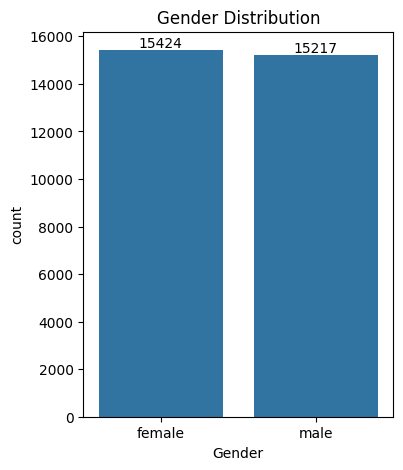

In [10]:
plt.figure(figsize=(4,5))
ax=sns.countplot(data=df , x="Gender")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show()

In [11]:
#Number of females are more than males

In [12]:
df["TotalScore"] = df["MathScore"] + df["ReadingScore"] + df["WritingScore"]
df["AverageScore"] = df["TotalScore"] / 3

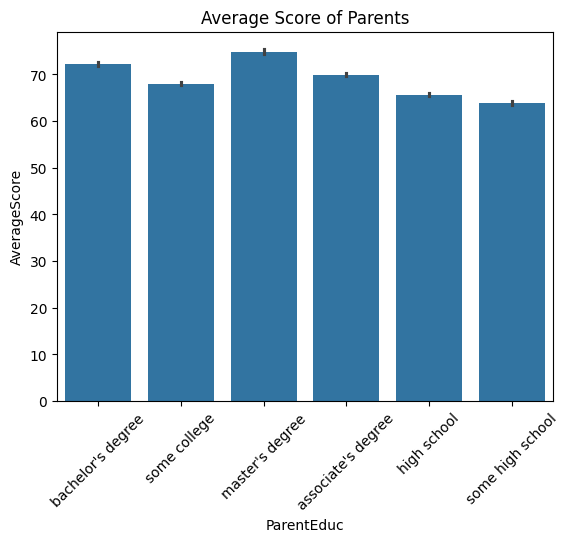

In [13]:
sns.barplot(x="ParentEduc", y="AverageScore", data=df)
plt.xticks(rotation=45)
plt.title("Average Score of Parents")
plt.show()

In [14]:
gb=df.groupby("ParentEduc").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})

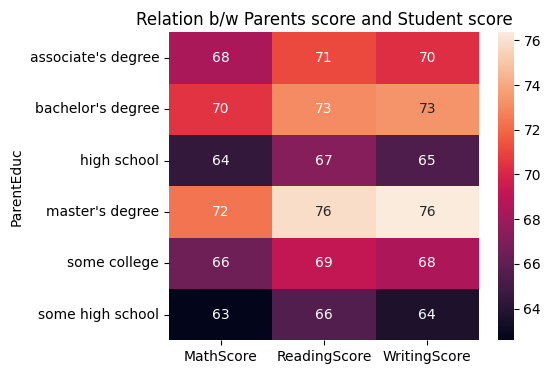

In [15]:
plt.figure(figsize=(5,4))
sns.heatmap(gb,annot=True)
plt.title("Relation b/w Parents score and Student score")
plt.show()

In [16]:
#This bar plot shows the relationship between parent education and student performance.
#I observed that students with more educated parents tend to have higher average scores.

In [17]:
Ms=df.groupby("ParentMaritalStatus").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})

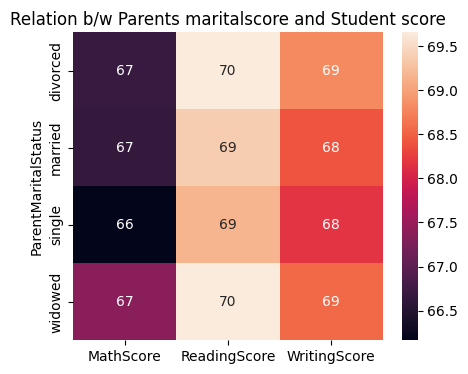

In [18]:
plt.figure(figsize=(5,4))
sns.heatmap(Ms,annot=True)
plt.title("Relation b/w Parents maritalscore and Student score")
plt.show()

In [19]:
#no such effect of Parent marital status on students.

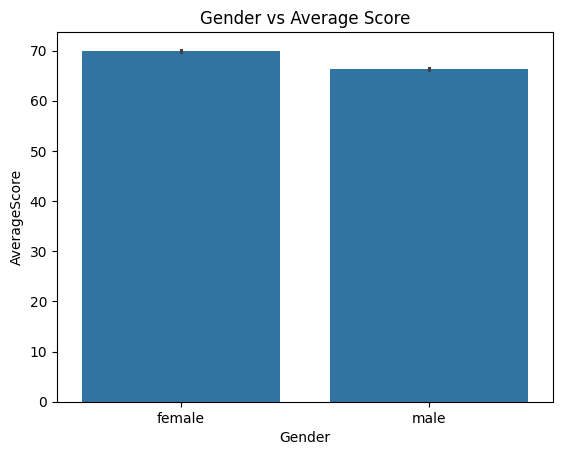

In [20]:
sns.barplot(x="Gender", y="AverageScore", data=df)
plt.title("Gender vs Average Score")
plt.show()

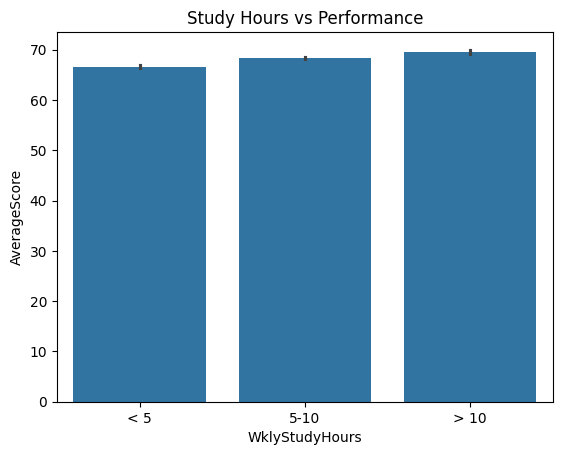

In [21]:
sns.barplot(x="WklyStudyHours", y="AverageScore", data=df)
plt.title("Study Hours vs Performance")
plt.show()

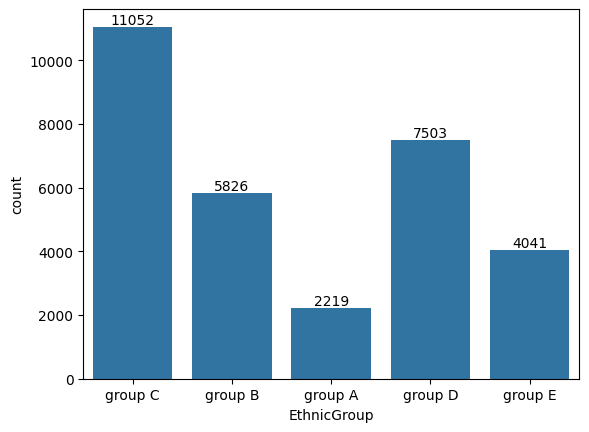

In [22]:
ax=sns.countplot(data=df,x="EthnicGroup")
ax.bar_label(ax.containers[0])
plt.show()

[np.int64(2219), np.int64(5826), np.int64(11052), np.int64(7503), np.int64(4041)]


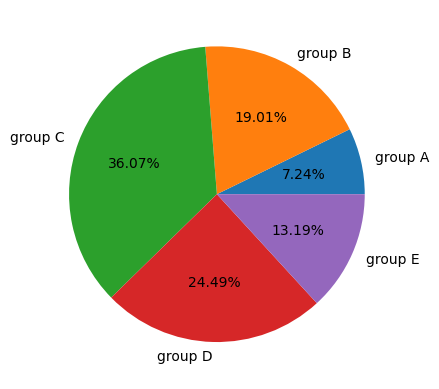

In [23]:
#Distribution of ethnic groups.
groupA=df.loc[(df["EthnicGroup"] == "group A")].count()
groupB=df.loc[(df["EthnicGroup"] == "group B")].count()
groupC=df.loc[(df["EthnicGroup"] == "group C")].count()
groupD=df.loc[(df["EthnicGroup"] == "group D")].count()
groupE=df.loc[(df["EthnicGroup"] == "group E")].count()

l=["group A","group B","group C","group D","group E"]
Elist=[groupA["EthnicGroup"], groupB["EthnicGroup"], groupC["EthnicGroup"], groupD["EthnicGroup"], groupE["EthnicGroup"]]
print(Elist)
plt.pie(Elist,labels=l, autopct="%1.2f%%")
plt.show()

In [24]:
df.to_csv("Cleaned_Student_Data.csv",index=False)